<a href="https://colab.research.google.com/github/PARZIVAL283/Churn-Customers-Prediction-using-Machine-Learning-Models/blob/main/Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

We are using the Predictive Analytics for Customer Churn dataset from Kaggle — a subscription streaming service with 21 columns and 243,000+ customers.

Download it here: https://www.kaggle.com/datasets/safrin03/predictive-analytics-for-customer-churn-dataset

It comes as two files — train.csv and test.csv. We will use train.csv for this project.

**Step 1 — Load and explore**

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


After running the cell above and allowing Google Drive access, your Drive will be mounted at `/content/drive`. You can then navigate through the file explorer on the left sidebar (folder icon) to find the exact path to your `train.csv` file. It will typically look something like `/content/drive/MyDrive/Your_Folder/train.csv`. Please update the `pd.read_csv` line in the next cell with this correct path.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid")

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Churn prediction /train.csv")
print(df.shape)
print(df.head())
print(df.isnull().sum())

print(df['Churn'].value_counts(normalize=True).round(3))

(243787, 21)
   AccountAge  MonthlyCharges  TotalCharges SubscriptionType  \
0          20       11.055215    221.104302          Premium   
1          57        5.175208    294.986882            Basic   
2          73       12.106657    883.785952            Basic   
3          32        7.263743    232.439774            Basic   
4          57       16.953078    966.325422          Premium   

      PaymentMethod PaperlessBilling ContentType MultiDeviceAccess  \
0      Mailed check               No        Both                No   
1       Credit card              Yes      Movies                No   
2      Mailed check              Yes      Movies                No   
3  Electronic check               No    TV Shows                No   
4  Electronic check              Yes    TV Shows                No   

  DeviceRegistered  ViewingHoursPerWeek  ...  ContentDownloadsPerMonth  \
0           Mobile            36.758104  ...                        10   
1           Tablet            32.

**Step 2 — Explore what drives churn**

---
Before building anything, understand who is churning and why.


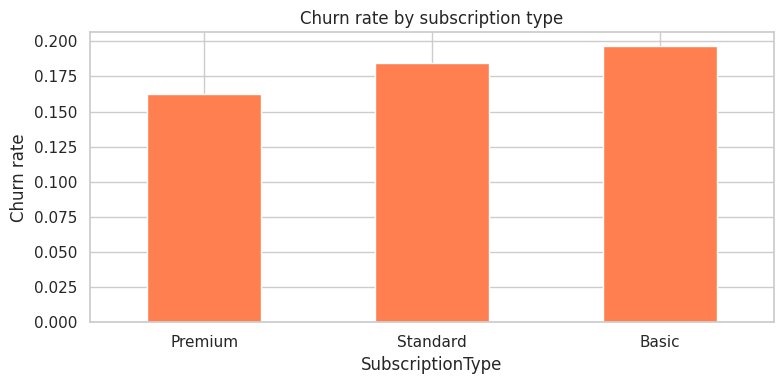

In [5]:
#subscription wise churn rate

churn_by_sub= df.groupby('SubscriptionType')['Churn'].mean().sort_values(ascending=True)
churn_by_sub.plot(kind='bar',color= 'coral', figsize=(8,4))
plt.title('Churn rate by subscription type')
plt.ylabel('Churn rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Basic subscribers churn at 19.7% vs 16.3% for Premium — customers on the cheapest plan are most at risk. This makes business sense: they have the least invested in the service.

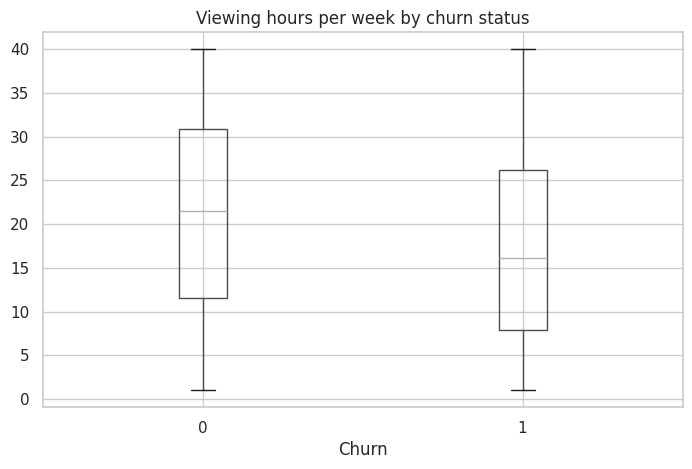

Churn
0    21.2
1    17.4
Name: ViewingHoursPerWeek, dtype: float64


In [6]:
#now let's see do they watch less content?

df.boxplot(column='ViewingHoursPerWeek',by='Churn',figsize=(8,5))
plt.title('Viewing hours per week by churn status')
plt.suptitle('')
plt.show()

print(df.groupby('Churn')['ViewingHoursPerWeek'].mean().round(1))

Churners watch an average of 17.4 hours per week vs 21.2 hours for retained customers. Low engagement is almost always a leading indicator of churn — if a customer stops watching, they are thinking about cancelling. That gives you a window to intervene before they do.

In [7]:
#churn customer with age
print(df.groupby('Churn')['AccountAge'].mean().round(1))

Churn
0    63.3
1    45.7
Name: AccountAge, dtype: float64


Churned customers have an average account age of 45.7 months vs 63.3 months for retained customers. Newer subscribers are significantly more at risk — the first few months are the critical retention window.

In [8]:
# Support tickets
print(df.groupby('Churn')['SupportTicketsPerMonth'].mean().round(1))

Churn
0    4.4
1    5.0
Name: SupportTicketsPerMonth, dtype: float64


Churners raise more support tickets on average (5.0 vs 4.4). A spike in support contacts is often a warning sign worth flagging to the customer success team.

**Step 3 — Prepare the data**

In [9]:
#delete customer ID column --- no needed
df = df.drop('CustomerID',axis=1)

# Encode categorical columns
cat_col=['SubscriptionType','PaymentMethod','PaperlessBilling',
         'ContentType','MultiDeviceAccess','DeviceRegistered',
         'GenrePreference','Gender','ParentalControl','SubtitlesEnabled']

le=LabelEncoder()
for col in cat_col:
  df[col]=le.fit_transform(df[col].astype(str))

#This dataset contains no missing values so no additional cleaning is required
#But it is good practice to always check


if df.isnull().sum().sum() > 0:
    df=df.dropna()

print(df.shape)

(243787, 20)


**Step 4 — Build the model**

In [10]:
X=df.drop('Churn',axis=1)
y=df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

Model = RandomForestClassifier(
    n_estimators=100,
    class_weight = 'balanced',
    random_state=42,
    n_jobs=1)


Model.fit(X_train, y_train)

y_pred = Model.predict(X_test)
y_prob = Model.predict_proba(X_test) # churn probability per customer

print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           0       0.83      0.99      0.90     39968
           1       0.55      0.05      0.10      8790

    accuracy                           0.82     48758
   macro avg       0.69      0.52      0.50     48758
weighted avg       0.78      0.82      0.76     48758



We are saving y_prob — the churn probability for every customer. We need this for the revenue layer in the next step.

**Step 5 — Evaluate properly**